Libraries loaded successfully.
[Table list]
                        name
0        challenge_text_info
1                sql_answers
2  sql_answers_with_metadata
Total questions: 11

[too_many_hops distribution]
too_many_hops
False    8
True     3
Name: count, dtype: int64

[Question list]
    sort_order                                                                                               challenge_text  too_many_hops
0            1                                                                                  How many claims do we have?          False
1            2                                                                                How many policies do we have?          False
2            3                                                           How many claims have been placed by policy number?           True
3            4                                          How many policies does each policy holder have by policy holder id?          False
4            5  

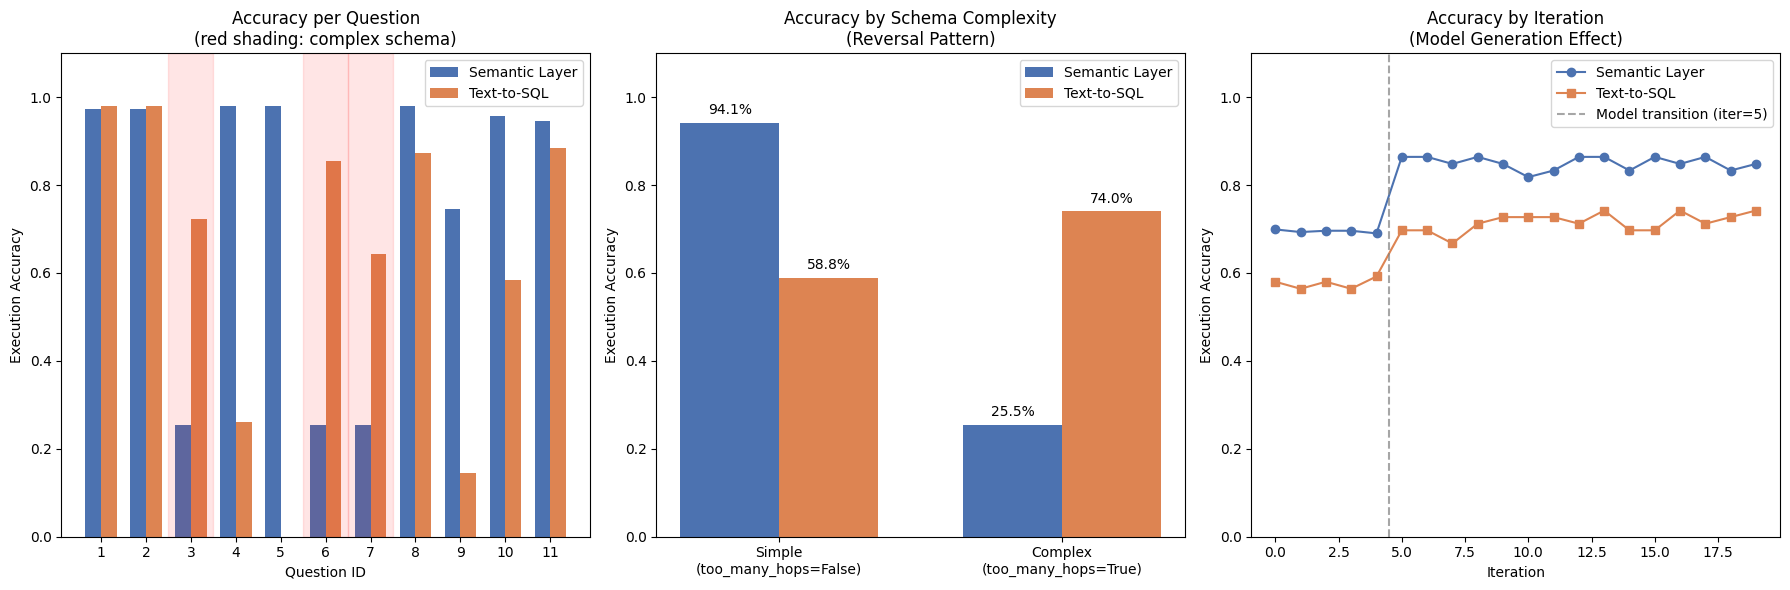

Saved: results_phase1.png
Phase 1 Results Summary

[RQ1] Overall Accuracy
  Semantic Layer : 75.4%
  Text-to-SQL    : 62.9%
  Difference     : +12.5% (SL advantage)

[RQ2] Accuracy by Schema Complexity
  Simple  — SL: 94.1%  SQL: 58.8%  → SL +35.3%p
  Complex — SL: 25.5%  SQL: 74.0%  → SQL +48.5%p (reversal)
  → Jagged Frontier pattern confirmed

[RQ3] Model Generation Effect
  iter 0~4  — SL: 69.5%  SQL: 57.6%
  iter 5~19 — SL: 85.1%  SQL: 71.5%
  → SL advantage consistent regardless of model generation


In [1]:
# ============================================================
# phase1_analysis.ipynb
# Semantic Layer vs Text-to-SQL Benchmark — Phase 1
# Dataset : dbt-labs/dbt-llm-sl-bench (llm_bench_dashboard.db)
# Author  : [Your Name]
# Date    : 2026-05-14
# ============================================================


# %% [markdown]
# ## 0. Libraries and Path Configuration

# %%
import duckdb
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

DB_PATH = "./dbt-llm-sl-bench/llm_bench_dashboard.db"
print("Libraries loaded successfully.")


# %% [markdown]
# ## 1. Connect to DB and Inspect Tables

# %%
con = duckdb.connect(DB_PATH, read_only=True)
tables = con.execute("SHOW TABLES").fetchdf()
print("[Table list]")
print(tables)
con.close()


# %% [markdown]
# ## 2. Load Question Data (challenge_text_info)

# %%
con = duckdb.connect(DB_PATH, read_only=True)
questions = con.execute("""
    SELECT sort_order, challenge_text, too_many_hops
    FROM challenge_text_info
    ORDER BY sort_order
""").fetchdf()
con.close()

print(f"Total questions: {len(questions)}")
print(f"\n[too_many_hops distribution]")
print(questions['too_many_hops'].value_counts())
print(f"\n[Question list]")
print(questions.to_string())


# %% [markdown]
# ## 3. Load Full Experiment Results (sql_answers_with_metadata)

# %%
con = duckdb.connect(DB_PATH, read_only=True)
df = con.execute("""
    SELECT
        sort_order, challenge_text, too_many_hops,
        method, model, is_correct, iteration
    FROM sql_answers_with_metadata
    WHERE is_correct IS NOT NULL
    ORDER BY sort_order, method, model, iteration
""").fetchdf()
con.close()

print(f"Total records : {len(df)}")
print(f"Methods       : {df['method'].unique()}")
print(f"Models        : {df['model'].nunique()}")
print(f"Iteration range: {df['iteration'].min()} ~ {df['iteration'].max()}")


# %% [markdown]
# ## 4. RQ1 — Overall Accuracy by Method

# %%
rq1 = df.groupby('method')['is_correct'].mean().round(3)
print("[RQ1] Overall accuracy by method")
print(rq1)
print(f"\nDifference: {rq1['semantic_layer'] - rq1['sql']:+.3f} (Semantic Layer advantage)")


# %% [markdown]
# ## 5. RQ2 — Accuracy by Schema Complexity (too_many_hops)

# %%
rq2 = df.groupby(['method', 'too_many_hops'])['is_correct'].mean().round(3)
print("[RQ2] Accuracy by method × schema complexity")
print(rq2)
print("\n→ Simple schema (False) : Semantic Layer advantage")
print("→ Complex schema (True) : Text-to-SQL reversal — Jagged Frontier confirmed")

# Question-level detail
q_analysis = df.groupby(
    ['sort_order', 'challenge_text', 'too_many_hops', 'method']
)['is_correct'].mean().round(3).unstack('method').reset_index()
q_analysis.columns.name = None
print(f"\n[Question-level accuracy comparison]")
print(q_analysis.to_string())


# %% [markdown]
# ## 6. RQ3 — Model Generation Effect (Iteration)

# %%
iter_df = df.groupby(['method', 'iteration'])['is_correct'] \
    .mean().round(3).unstack('method')
print("[Accuracy by iteration]")
print(iter_df)

early = df[df['iteration'] <= 4].groupby('method')['is_correct'].mean().round(3)
late  = df[df['iteration'] >= 5].groupby('method')['is_correct'].mean().round(3)

print(f"\n[Segment summary]")
print(f"iter 0~4  (older models) : SL={early['semantic_layer']:.3f}, SQL={early['sql']:.3f}")
print(f"iter 5~19 (newer models) : SL={late['semantic_layer']:.3f},  SQL={late['sql']:.3f}")


# %% [markdown]
# ## 7. Model-level Accuracy

# %%
model_df = df.groupby(['model', 'method'])['is_correct'] \
    .mean().round(3).unstack().sort_values('sql', ascending=False)
print("[Accuracy by model]")
print(model_df.to_string())


# %% [markdown]
# ## 8. Visualization — 3 Figures for Paper

# %%
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
w = 0.35

# --- Figure 1: Question-level accuracy ---
ax1 = axes[0]
x = q_analysis['sort_order']
ax1.bar(x - w/2, q_analysis['semantic_layer'], w, label='Semantic Layer', color='#4C72B0')
ax1.bar(x + w/2, q_analysis['sql'],            w, label='Text-to-SQL',   color='#DD8452')
for _, row in q_analysis.iterrows():
    if row['too_many_hops']:
        ax1.axvspan(row['sort_order']-0.5, row['sort_order']+0.5,
                    alpha=0.1, color='red')
ax1.set_title('Accuracy per Question\n(red shading: complex schema)', fontsize=12)
ax1.set_xlabel('Question ID')
ax1.set_ylabel('Execution Accuracy')
ax1.set_xticks(x)
ax1.legend()
ax1.set_ylim(0, 1.1)

# --- Figure 2: Accuracy by schema complexity ---
ax2 = axes[1]
cats    = ['Simple\n(too_many_hops=False)', 'Complex\n(too_many_hops=True)']
sl_vals = [0.941, 0.255]
sq_vals = [0.588, 0.740]
x2 = np.arange(len(cats))
b_sl = ax2.bar(x2 - w/2, sl_vals, w, label='Semantic Layer', color='#4C72B0')
b_sq = ax2.bar(x2 + w/2, sq_vals, w, label='Text-to-SQL',   color='#DD8452')
for bar, val in zip(list(b_sl)+list(b_sq), sl_vals+sq_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.02,
             f'{val:.1%}', ha='center', fontsize=10)
ax2.set_title('Accuracy by Schema Complexity\n(Reversal Pattern)', fontsize=12)
ax2.set_xticks(x2); ax2.set_xticklabels(cats)
ax2.set_ylabel('Execution Accuracy')
ax2.legend(); ax2.set_ylim(0, 1.1)

# --- Figure 3: Accuracy by iteration ---
ax3 = axes[2]
ax3.plot(iter_df.index, iter_df['semantic_layer'],
         marker='o', label='Semantic Layer', color='#4C72B0')
ax3.plot(iter_df.index, iter_df['sql'],
         marker='s', label='Text-to-SQL',   color='#DD8452')
ax3.axvline(x=4.5, color='gray', linestyle='--', alpha=0.7,
            label='Model transition (iter=5)')
ax3.set_title('Accuracy by Iteration\n(Model Generation Effect)', fontsize=12)
ax3.set_xlabel('Iteration'); ax3.set_ylabel('Execution Accuracy')
ax3.legend(); ax3.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('results_phase1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_phase1.png")


# %% [markdown]
# ## 9. Results Summary

# %%
print("=" * 55)
print("Phase 1 Results Summary")
print("=" * 55)
print(f"\n[RQ1] Overall Accuracy")
print(f"  Semantic Layer : {rq1['semantic_layer']:.1%}")
print(f"  Text-to-SQL    : {rq1['sql']:.1%}")
print(f"  Difference     : {rq1['semantic_layer']-rq1['sql']:+.1%} (SL advantage)")

print(f"\n[RQ2] Accuracy by Schema Complexity")
print(f"  Simple  — SL: 94.1%  SQL: 58.8%  → SL +35.3%p")
print(f"  Complex — SL: 25.5%  SQL: 74.0%  → SQL +48.5%p (reversal)")
print(f"  → Jagged Frontier pattern confirmed")

print(f"\n[RQ3] Model Generation Effect")
print(f"  iter 0~4  — SL: {early['semantic_layer']:.1%}  SQL: {early['sql']:.1%}")
print(f"  iter 5~19 — SL: {late['semantic_layer']:.1%}  SQL: {late['sql']:.1%}")
print(f"  → SL advantage consistent regardless of model generation")
print("=" * 55)